- Extrair caracteristicas de cada ST com TSfresh -- estatistica descritiva globais no pre e pos de cada audio -- amostras emparelhadas para comparar pre com pos

- Medir semelhanças entre o pre e pos -- medida de de distancia entre séries temporais -- DTW (dominio temporal) + dominio frequuencia (alex)

- diferenças entre pares e posterior clustering desses valores

- organizar os dados para trabalhar no spss, o mesmo individuo deve estar na mesma linha com o pre e o pos, cada 




----- Verificar no codigo do programa se ao mexer nos parametros nao altera o audio por algum motivo e os valores de energia pre e pos 0,5s nao ficam alterados por isso ----

### 1. Data feature extraction and file preparation

In [41]:
# Cell 1: Imports and setup
import pandas as pd
from tsfresh import extract_features
from tsfresh import select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters, MinimalFCParameters
import numpy as np
from scipy import stats
from tslearn.clustering import TimeSeriesKMeans
from tslearn.metrics import dtw, dtw_path
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.utils import to_time_series_dataset
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import warnings
warnings.filterwarnings('ignore') 

# For better display in Jupyter
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Only works with python3 version 3.11 or bellow due to the cwt function from scipy

c:\Users\Teresa\anaconda3\Lib\site-packages\tsfresh\__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\Teresa\anaconda3\Lib\site-packages\tslearn\bases\bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [2]:
# Cell 2: Load and explore data
import re

df = pd.read_csv(r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\Data\SPL_data.csv")

# Check and fill missing values
missing_count = df['volume_ml'].isnull().sum()

if missing_count > 0:
    print(f"Found {missing_count} missing volume_ml values - filling from filenames...")
    
    def extract_volume_from_filename(filename):
        match = re.search(r'(\d+(?:\.\d+)?)[mM][lL]', filename)
        if match:
            return float(match.group(1))
        return None
    
    df.loc[df['volume_ml'].isnull(), 'volume_ml'] = df.loc[df['volume_ml'].isnull(), 'audio_file'].apply(extract_volume_from_filename)
    print(f"✓ Filled successfully! Remaining missing: {df['volume_ml'].isnull().sum()}\n")

# Convert to integers
df['volume_ml'] = df['volume_ml'].astype(int)
df['expected_swallows'] = df['expected_swallows'].astype(int)
df['detected_swallows'] = df['detected_swallows'].astype(int)

# Display summary
print(f"Data shape: {df.shape}")
print(f"\nMissing values per column:")
print(df.isnull().sum())

print("\n" + "="*80)
print("First 10 rows:")
display(df.head(10))

print("\n" + "="*80)
print("Variables:")
print(f"  • Unique audio files: {df['audio_file'].nunique()}")
print(f"  • Segment types: {df['segment_type'].unique()}")
print(f"  • Groups: {df['group'].unique()}")
print(f"  • Volume values (ml): {sorted(df['volume_ml'].unique())}")

Found 1104 missing volume_ml values - filling from filenames...
✓ Filled successfully! Remaining missing: 0

Data shape: (41584, 8)

Missing values per column:
audio_file           0
segment_type         0
frequency_hz         0
spl_db               0
detected_swallows    0
expected_swallows    0
group                0
volume_ml            0
dtype: int64

First 10 rows:


,audio_file,segment_type,frequency_hz,spl_db,detected_swallows,expected_swallows,group,volume_ml
0,GC-F10-10ml.wav,pre_swallow,21.533203,31.061598,2,2,Control,10
1,GC-F10-10ml.wav,pre_swallow,32.299805,38.162357,2,2,Control,10
2,GC-F10-10ml.wav,pre_swallow,43.066406,40.669239,2,2,Control,10
3,GC-F10-10ml.wav,pre_swallow,53.833008,41.282619,2,2,Control,10
4,GC-F10-10ml.wav,pre_swallow,64.599609,39.009421,2,2,Control,10
5,GC-F10-10ml.wav,pre_swallow,75.366211,34.653134,2,2,Control,10
6,GC-F10-10ml.wav,pre_swallow,86.132812,30.625066,2,2,Control,10
7,GC-F10-10ml.wav,pre_swallow,96.899414,28.764773,2,2,Control,10
8,GC-F10-10ml.wav,pre_swallow,107.666016,27.122089,2,2,Control,10
9,GC-F10-10ml.wav,pre_swallow,118.432617,24.627552,2,2,Control,10



Variables:
  • Unique audio files: 107
  • Segment types: ['pre_swallow' 'post_swallow']
  • Groups: ['Control' 'Study']
  • Volume values (ml): [3, 5, 10, 20, 50]


In [3]:
# Cell 3: Prepare time series data
timeseries_df = df[['audio_file', 'segment_type', 'frequency_hz', 'spl_db']].copy()
timeseries_df['id'] = timeseries_df['audio_file'] + '_' + timeseries_df['segment_type']

print(f"Number of unique time series: {timeseries_df['id'].nunique()}")
display(timeseries_df.head())

Number of unique time series: 214


,audio_file,segment_type,frequency_hz,spl_db,id
0,GC-F10-10ml.wav,pre_swallow,21.533203,31.061598,GC-F10-10ml.wav_pre_swallow
1,GC-F10-10ml.wav,pre_swallow,32.299805,38.162357,GC-F10-10ml.wav_pre_swallow
2,GC-F10-10ml.wav,pre_swallow,43.066406,40.669239,GC-F10-10ml.wav_pre_swallow
3,GC-F10-10ml.wav,pre_swallow,53.833008,41.282619,GC-F10-10ml.wav_pre_swallow
4,GC-F10-10ml.wav,pre_swallow,64.599609,39.009421,GC-F10-10ml.wav_pre_swallow


In [4]:
%%time
# Cell 4: Extract features 
print("Extracting comprehensive features from tsfresh...")
print("This includes: FFT, autocorrelation, entropy, complexity, wavelets, and more")
print(f"Processing {timeseries_df['id'].nunique()} time series...")
print("Progress bar will appear below (this may take 2-10 minutes):\n")

extracted_features = extract_features(
    timeseries_df,
    column_id='id',
    column_sort='frequency_hz',
    column_value='spl_db',
    default_fc_parameters=ComprehensiveFCParameters(),  # ALL FEATURES!
    impute_function=impute,
    disable_progressbar=False
)

print(f"\n{'='*80}")
print("✓ Feature extraction complete!")
print(f"{'='*80}")
print(f"Extracted features shape: {extracted_features.shape}")
print(f"Number of time series: {extracted_features.shape[0]}")
print(f"Total features per series: {extracted_features.shape[1]}")

# Show examples of different feature types
print(f"\n{'='*80}")
print("Sample of extracted feature types:")
print(f"{'='*80}")
feature_names = extracted_features.columns.tolist()

feature_types = {
    'Basic statistics': [f for f in feature_names if any(x in f for x in ['mean', 'std', 'variance', 'median'])],
    'FFT coefficients': [f for f in feature_names if 'fft_coefficient' in f],
    'Autocorrelation': [f for f in feature_names if 'autocorrelation' in f],
    'Entropy measures': [f for f in feature_names if 'entropy' in f],
    'Complexity': [f for f in feature_names if 'complexity' in f or 'c3' in f],
    'Quantiles': [f for f in feature_names if 'quantile' in f],
}

for ftype, features in feature_types.items():
    if features:
        print(f"\n{ftype}: {len(features)} features")
        print(f"  Examples: {features[:3]}")

print(f"\n{'='*80}")
print("First 5 rows preview:")
display(extracted_features.head())

Extracting comprehensive features from tsfresh...
This includes: FFT, autocorrelation, entropy, complexity, wavelets, and more
Processing 214 time series...
Progress bar will appear below (this may take 2-10 minutes):



Feature Extraction: 100%|██████████| 36/36 [00:06<00:00,  5.89it/s]



✓ Feature extraction complete!
Extracted features shape: (214, 783)
Number of time series: 214
Total features per series: 783

Sample of extracted feature types:

Basic statistics: 68 features
  Examples: ['spl_db__variance_larger_than_standard_deviation', 'spl_db__mean_abs_change', 'spl_db__mean_change']

FFT coefficients: 400 features
  Examples: ['spl_db__fft_coefficient__attr_"real"__coeff_0', 'spl_db__fft_coefficient__attr_"real"__coeff_1', 'spl_db__fft_coefficient__attr_"real"__coeff_2']

Autocorrelation: 23 features
  Examples: ['spl_db__autocorrelation__lag_0', 'spl_db__autocorrelation__lag_1', 'spl_db__autocorrelation__lag_2']

Entropy measures: 17 features
  Examples: ['spl_db__sample_entropy', 'spl_db__binned_entropy__max_bins_10', 'spl_db__approximate_entropy__m_2__r_0.1']

Complexity: 8 features
  Examples: ['spl_db__c3__lag_1', 'spl_db__c3__lag_2', 'spl_db__c3__lag_3']

Quantiles: 76 features
  Examples: ['spl_db__quantile__q_0.1', 'spl_db__quantile__q_0.2', 'spl_db__qua

,spl_db__variance_larger_than_standard_deviation,spl_db__has_duplicate_max,spl_db__has_duplicate_min,spl_db__has_duplicate,spl_db__sum_values,spl_db__abs_energy,spl_db__mean_abs_change,spl_db__mean_change,spl_db__mean_second_derivative_central,spl_db__median,spl_db__mean,spl_db__length,spl_db__standard_deviation,spl_db__variation_coefficient,spl_db__variance,spl_db__skewness,spl_db__kurtosis,spl_db__root_mean_square,spl_db__absolute_sum_of_changes,spl_db__longest_strike_below_mean,spl_db__longest_strike_above_mean,spl_db__count_above_mean,spl_db__count_below_mean,spl_db__last_location_of_maximum,spl_db__first_location_of_maximum,spl_db__last_location_of_minimum,spl_db__first_location_of_minimum,spl_db__percentage_of_reoccurring_values_to_all_values,spl_db__percentage_of_reoccurring_datapoints_to_all_datapoints,spl_db__sum_of_reoccurring_values,spl_db__sum_of_reoccurring_data_points,spl_db__ratio_value_number_to_time_series_length,spl_db__sample_entropy,spl_db__maximum,spl_db__absolute_maximum,spl_db__minimum,spl_db__benford_correlation,spl_db__time_reversal_asymmetry_statistic__lag_1,spl_db__time_reversal_asymmetry_statistic__lag_2,spl_db__time_reversal_asymmetry_statistic__lag_3,spl_db__c3__lag_1,spl_db__c3__lag_2,spl_db__c3__lag_3,spl_db__cid_ce__normalize_True,spl_db__cid_ce__normalize_False,spl_db__symmetry_looking__r_0.0,spl_db__symmetry_looking__r_0.05,spl_db__symmetry_looking__r_0.1,spl_db__symmetry_looking__r_0.15000000000000002,spl_db__symmetry_looking__r_0.2,spl_db__symmetry_looking__r_0.25,spl_db__symmetry_looking__r_0.30000000000000004,spl_db__symmetry_looking__r_0.35000000000000003,spl_db__symmetry_looking__r_0.4,spl_db__symmetry_looking__r_0.45,spl_db__symmetry_looking__r_0.5,spl_db__symmetry_looking__r_0.55,spl_db__symmetry_looking__r_0.6000000000000001,spl_db__symmetry_looking__r_0.65,spl_db__symmetry_looking__r_0.7000000000000001,spl_db__symmetry_looking__r_0.75,spl_db__symmetry_looking__r_0.8,spl_db__symmetry_looking__r_0.8500000000000001,spl_db__symmetry_looking__r_0.9,spl_db__symmetry_looking__r_0.9500000000000001,spl_db__large_standard_deviation__r_0.05,spl_db__large_standard_deviation__r_0.1,spl_db__large_standard_deviation__r_0.15000000000000002,spl_db__large_standard_deviation__r_0.2,spl_db__large_standard_deviation__r_0.25,spl_db__large_standard_deviation__r_0.30000000000000004,spl_db__large_standard_deviation__r_0.35000000000000003,spl_db__large_standard_deviation__r_0.4,spl_db__large_standard_deviation__r_0.45,spl_db__large_standard_deviation__r_0.5,spl_db__large_standard_deviation__r_0.55,spl_db__large_standard_deviation__r_0.6000000000000001,spl_db__large_standard_deviation__r_0.65,spl_db__large_standard_deviation__r_0.7000000000000001,spl_db__large_standard_deviation__r_0.75,spl_db__large_standard_deviation__r_0.8,spl_db__large_standard_deviation__r_0.8500000000000001,spl_db__large_standard_deviation__r_0.9,spl_db__large_standard_deviation__r_0.9500000000000001,spl_db__quantile__q_0.1,spl_db__quantile__q_0.2,spl_db__quantile__q_0.3,spl_db__quantile__q_0.4,spl_db__quantile__q_0.6,spl_db__quantile__q_0.7,spl_db__quantile__q_0.8,spl_db__quantile__q_0.9,spl_db__autocorrelation__lag_0,spl_db__autocorrelation__lag_1,spl_db__autocorrelation__lag_2,spl_db__autocorrelation__lag_3,spl_db__autocorrelation__lag_4,spl_db__autocorrelation__lag_5,spl_db__autocorrelation__lag_6,spl_db__autocorrelation__lag_7,spl_db__autocorrelation__lag_8,spl_db__autocorrelation__lag_9,"spl_db__agg_autocorrelation__f_agg_""mean""__maxlag_40","spl_db__agg_autocorrelation__f_agg_""median""__maxlag_40","spl_db__agg_autocorrelation__f_agg_""var""__maxlag_40",spl_db__partial_autocorrelation__lag_0,spl_db__partial_autocorrelation__lag_1,spl_db__partial_autocorrelation__lag_2,spl_db__partial_autocorrelation__lag_3,spl_db__partial_autocorrelation__lag_4,spl_db__partial_autocorrelation__lag_5,spl_db__partial_autocorrelation__lag_6,spl_db__partial_autocorrelation__lag_7,spl_db__partial_autocorrelation__lag_8,spl_db__partial_autocorrelation

CPU times: total: 500 ms
Wall time: 6.53 s


NameError: name 'feature_names' is not defined

In [5]:
# Cell 5: Restructure features for SPSS (one row per audio file)

print("Restructuring features for SPSS analysis...")
print("Format: One row per audio file with all pre features, then all post features\n")

# Reset index to get 'id' as a column
features_reset = extracted_features.copy()
features_reset['id'] = features_reset.index

# Split ID into audio_file and segment_type
def split_audio_and_segment(id_str):
    if id_str.endswith('_post_swallow'):
        audio_file = id_str.replace('_post_swallow', '')
        segment_type = 'post_swallow'
    elif id_str.endswith('_pre_swallow'):
        audio_file = id_str.replace('_pre_swallow', '')
        segment_type = 'pre_swallow'
    else:
        # Fallback
        parts = id_str.rsplit('_', 2)
        audio_file = parts[0]
        segment_type = '_'.join(parts[1:])
    return audio_file, segment_type

features_reset[['audio_file', 'segment_type']] = features_reset['id'].apply(
    lambda x: pd.Series(split_audio_and_segment(x))
)

print("✓ IDs parsed correctly")
print(f"  Unique audio files: {features_reset['audio_file'].nunique()}")
print(f"  Segment types: {features_reset['segment_type'].unique()}")

# Get feature columns
feature_cols = [col for col in features_reset.columns if col not in ['id', 'audio_file', 'segment_type']]

# Pivot to wide format
features_wide = features_reset.pivot(
    index='audio_file',
    columns='segment_type',
    values=feature_cols
)

# Flatten column names: feature_name_segment_type
features_wide.columns = [f"{col[0]}_{col[1]}" for col in features_wide.columns]

# Reset index
features_wide = features_wide.reset_index()

# Reorder columns: audio_file, then all pre_swallow, then all post_swallow
pre_cols = sorted([col for col in features_wide.columns if col.endswith('_pre_swallow')])
post_cols = sorted([col for col in features_wide.columns if col.endswith('_post_swallow')])

features_wide = features_wide[['audio_file'] + pre_cols + post_cols]

print(f"\n{'='*80}")
print("✓ Data restructured successfully!")
print(f"{'='*80}")
print(f"Shape: {features_wide.shape}")
print(f"  • Rows (audio files): {features_wide.shape[0]}")
print(f"  • Total columns: {features_wide.shape[1]}")
print(f"  • Pre_swallow features: {len(pre_cols)}")
print(f"  • Post_swallow features: {len(post_cols)}")

print("\nColumn structure:")
print(f"  Column 1: audio_file")
print(f"  Columns 2-{len(pre_cols)+1}: All pre_swallow features")
print(f"  Columns {len(pre_cols)+2}-{len(features_wide.columns)}: All post_swallow features")

print("\nFirst 5 columns:")
print(features_wide.columns[:5].tolist())

print("\nFirst pre→post transition:")
print(f"  Last pre: {pre_cols[-1]}")
print(f"  First post: {post_cols[0]}")

display(features_wide.head())

Restructuring features for SPSS analysis...
Format: One row per audio file with all pre features, then all post features

✓ IDs parsed correctly
  Unique audio files: 107
  Segment types: ['post_swallow' 'pre_swallow']

✓ Data restructured successfully!
Shape: (107, 1567)
  • Rows (audio files): 107
  • Total columns: 1567
  • Pre_swallow features: 783
  • Post_swallow features: 783

Column structure:
  Column 1: audio_file
  Columns 2-784: All pre_swallow features
  Columns 785-1567: All post_swallow features

First 5 columns:
['audio_file', 'spl_db__abs_energy_pre_swallow', 'spl_db__absolute_maximum_pre_swallow', 'spl_db__absolute_sum_of_changes_pre_swallow', 'spl_db__agg_autocorrelation__f_agg_"mean"__maxlag_40_pre_swallow']

First pre→post transition:
  Last pre: spl_db__variation_coefficient_pre_swallow
  First post: spl_db__abs_energy_post_swallow


audio_file  spl_db__abs_energy_pre_swallow  \
0  GC-F10-10ml.wav                   112518.788286   
1  GC-F10-20ml.wav                   143200.739776   
2   GC-F10-3ml.wav                   156887.346914   
3  GC-F10-50ml.wav                   200491.588969   
4   GC-F10-5ml.wav                   133737.922495   

   spl_db__absolute_maximum_pre_swallow  \
0                             83.230873   
1                             95.660832   
2                             99.243326   
3                             91.096221   
4                             93.653386   

   spl_db__absolute_sum_of_changes_pre_swallow  \
0                                   287.953433   
1                                   312.932123   
2                                   305.790041   
3                                   268.399183   
4                                   330.414908   

   spl_db__agg_autocorrelation__f_agg_"mean"__maxlag_40_pre_swallow  \
0                                           0.591706                  
1                                           0.492646                  
2                                           0.575539                  
3                                           0.469246                  
4                                           0.614901                  

   spl_db__agg_autocorrelation__f_agg_"median"__maxlag_40_pre_swallow  \
0                                           0.593840                    
1                                           0.486761                    
2                                           0.596064                    
3                                           0.452168                    
4                                           0.622848                    

   spl_db__agg_autocorrelation__f_agg_"var"__maxlag_40_pre_swallow  \
0                                           0.031220                 
1                                           0.042903                 
2                                           0.031157                 
3                                           0.048511                 
4                                           0.029742                 

   spl_db__agg_linear_trend__attr_"intercept"__chunk_len_10__f_agg_"max"_pre_swallow  \
0                                          26.342540                                   
1                                          13.637728                                   
2                                          17.519691                                   
3                                           1.773804                                   
4                                          28.292350                                   

   spl_db__agg_linear_trend__attr_"intercept"__chunk_len_10__f_agg_"mean"_pre_swallow  \
0                                          23.012362                                    
1                                          10.343108                                    
2                                          13.940927                                    
3                                          -1.061258                                    
4                                          25.542866                                    

   spl_db__agg_linear_trend__attr_"intercept"__chunk_len_10__f_agg_"min"_pre_swallow  \
0                                          19.320550                                   
1                                           7.538747                                   
2                                          12.092320                                   
3                                          -4.457673                                   
4                                          23.061045                                   

   spl_db__agg_linear_trend__attr_"intercept"__chunk_len_10__f_agg_"var"_pre_swallow  \
0                                           2.299964                                   
1                                          -3.580882               

In [6]:
# Cell 6: Add metadata and save to CSV for SPSS

# Get metadata per audio file
metadata_per_file = df.groupby('audio_file').agg({
    'detected_swallows': 'first',
    'expected_swallows': 'first',
    'group': 'first',
    'volume_ml': 'first'
}).reset_index()

# Merge metadata with features
final_data = features_wide.merge(
    metadata_per_file,
    on='audio_file',
    how='left'
)

# Reorder columns: metadata first, then all features
metadata_cols = ['audio_file', 'group', 'volume_ml', 'detected_swallows', 'expected_swallows']
feature_cols = [col for col in final_data.columns if col not in metadata_cols]

# Put metadata at the beginning
final_data = final_data[metadata_cols + feature_cols]

print("="*80)
print("FINAL DATASET FOR SPSS")
print("="*80)
print(f"Shape: {final_data.shape}")
print(f"  • Rows (audio files): {final_data.shape[0]}")
print(f"  • Total columns: {final_data.shape[1]}")
print(f"    - Metadata columns: {len(metadata_cols)}")
print(f"    - Feature columns: {len(feature_cols)}")

print("\nColumn order:")
print(f"  1-5: Metadata (audio_file, group, volume_ml, detected_swallows, expected_swallows)")
print(f"  6-{len(pre_cols)+5}: Pre_swallow features ({len(pre_cols)} features)")
print(f"  {len(pre_cols)+6}-{final_data.shape[1]}: Post_swallow features ({len(post_cols)} features)")

display(final_data.head())

# Save to CSV
output_file = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\Data\tsfresh_features_SPSS.csv"
final_data.to_csv(output_file, index=False)

print(f"\n{'='*80}")
print(f"✓ SUCCESS! File saved to:")
print(f"  {output_file}")
print(f"\n✓ Ready to import into SPSS!")
print(f"{'='*80}")

FINAL DATASET FOR SPSS
Shape: (107, 1571)
  • Rows (audio files): 107
  • Total columns: 1571
    - Metadata columns: 5
    - Feature columns: 1566

Column order:
  1-5: Metadata (audio_file, group, volume_ml, detected_swallows, expected_swallows)
  6-788: Pre_swallow features (783 features)
  789-1571: Post_swallow features (783 features)


audio_file    group  volume_ml  detected_swallows  expected_swallows  \
0  GC-F10-10ml.wav  Control         10                  2                  2   
1  GC-F10-20ml.wav  Control         20                  2                  2   
2   GC-F10-3ml.wav  Control          3                  1                  1   
3  GC-F10-50ml.wav  Control         50                  5                  5   
4   GC-F10-5ml.wav  Control          5                  1                  1   

   spl_db__abs_energy_pre_swallow  spl_db__absolute_maximum_pre_swallow  \
0                   112518.788286                             83.230873   
1                   143200.739776                             95.660832   
2                   156887.346914                             99.243326   
3                   200491.588969                             91.096221   
4                   133737.922495                             93.653386   

   spl_db__absolute_sum_of_changes_pre_swallow  \
0                                   287.953433   
1                                   312.932123   
2                                   305.790041   
3                                   268.399183   
4                                   330.414908   

   spl_db__agg_autocorrelation__f_agg_"mean"__maxlag_40_pre_swallow  \
0                                           0.591706                  
1                                           0.492646                  
2                                           0.575539                  
3                                           0.469246                  
4                                           0.614901                  

   spl_db__agg_autocorrelation__f_agg_"median"__maxlag_40_pre_swallow  \
0                                           0.593840                    
1                                           0.486761                    
2                                           0.596064                    
3                                           0.452168                    
4                                           0.622848                    

   spl_db__agg_autocorrelation__f_agg_"var"__maxlag_40_pre_swallow  \
0                                           0.031220                 
1                                           0.042903                 
2                                           0.031157                 
3                                           0.048511                 
4                                           0.029742                 

   spl_db__agg_linear_trend__attr_"intercept"__chunk_len_10__f_agg_"max"_pre_swallow  \
0                                          26.342540                                   
1                                          13.637728                                   
2                                          17.519691                                   
3                                           1.773804                                   
4                                          28.292350                                   

   spl_db__agg_linear_trend__attr_"intercept"__chunk_len_10__f_agg_"mean"_pre_swallow  \
0                                          23.012362                                    
1                                          10.343108                                    
2                                          13.940927                                    
3                                          -1.061258                                    
4                                          25.542866                                    

   spl_db__agg_linear_trend__attr_"intercept"__chunk_len_10__f_agg_"min"_pre_swallow  \
0                                          19.320550                                   
1                                           7.538747                                   
2                                          12.092320                                   
3                                          -4.457673                    


✓ SUCCESS! File saved to:
  C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\Data\tsfresh_features_SPSS.csv

✓ Ready to import into SPSS!


### 2. Data preparation and cleaning

In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

file_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\Data\tsfresh_features_SPSS.csv"

df = pd.read_csv(file_path)
original_shape = df.shape

print(f"📊 Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nFirst few rows:")
df.head()

📊 Data loaded successfully!
Shape: (107, 1571)
Memory usage: 1.29 MB

First few rows:


audio_file    group  volume_ml  detected_swallows  expected_swallows  \
0  GC-F10-10ml.wav  Control         10                  2                  2   
1  GC-F10-20ml.wav  Control         20                  2                  2   
2   GC-F10-3ml.wav  Control          3                  1                  1   
3  GC-F10-50ml.wav  Control         50                  5                  5   
4   GC-F10-5ml.wav  Control          5                  1                  1   

   spl_db__abs_energy_pre_swallow  spl_db__absolute_maximum_pre_swallow  \
0                   112518.788286                             83.230873   
1                   143200.739776                             95.660832   
2                   156887.346914                             99.243326   
3                   200491.588969                             91.096221   
4                   133737.922495                             93.653386   

   spl_db__absolute_sum_of_changes_pre_swallow  \
0                                   287.953433   
1                                   312.932123   
2                                   305.790041   
3                                   268.399183   
4                                   330.414908   

   spl_db__agg_autocorrelation__f_agg_"mean"__maxlag_40_pre_swallow  \
0                                           0.591706                  
1                                           0.492646                  
2                                           0.575539                  
3                                           0.469246                  
4                                           0.614901                  

   spl_db__agg_autocorrelation__f_agg_"median"__maxlag_40_pre_swallow  \
0                                           0.593840                    
1                                           0.486761                    
2                                           0.596064                    
3                                           0.452168                    
4                                           0.622848                    

   spl_db__agg_autocorrelation__f_agg_"var"__maxlag_40_pre_swallow  \
0                                           0.031220                 
1                                           0.042903                 
2                                           0.031157                 
3                                           0.048511                 
4                                           0.029742                 

   spl_db__agg_linear_trend__attr_"intercept"__chunk_len_10__f_agg_"max"_pre_swallow  \
0                                          26.342540                                   
1                                          13.637728                                   
2                                          17.519691                                   
3                                           1.773804                                   
4                                          28.292350                                   

   spl_db__agg_linear_trend__attr_"intercept"__chunk_len_10__f_agg_"mean"_pre_swallow  \
0                                          23.012362                                    
1                                          10.343108                                    
2                                          13.940927                                    
3                                          -1.061258                                    
4                                          25.542866                                    

   spl_db__agg_linear_trend__attr_"intercept"__chunk_len_10__f_agg_"min"_pre_swallow  \
0                                          19.320550                                   
1                                           7.538747                                   
2                                          12.092320                                   
3                                          -4.457673                    

In [8]:
id_patterns = ['id', 'audio_file', 'segment', 'sample', 'series', 'file', 'name']
id_columns = []

# Check for non-numeric columns first
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
id_columns.extend(non_numeric_cols)

# Check for columns with ID patterns
for col in df.columns:
    if any(pattern in col.lower() for pattern in id_patterns) and col not in id_columns:
        id_columns.append(col)

# All other columns are features
feature_columns = [col for col in df.columns if col not in id_columns]

print(f"🎯 Column Classification:")
print(f"ID columns ({len(id_columns)}): {id_columns}")
print(f"Feature columns: {len(feature_columns)} features")
print(f"\nSample feature names:")
for i, col in enumerate(feature_columns[:10]):
    print(f"  {i+1}. {col}")
if len(feature_columns) > 10:
    print(f"  ... and {len(feature_columns) - 10} more")

🎯 Column Classification:
ID columns (152): ['audio_file', 'group', 'spl_db__cid_ce__normalize_False_pre_swallow', 'spl_db__cid_ce__normalize_True_pre_swallow', 'spl_db__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)_pre_swallow', 'spl_db__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)_pre_swallow', 'spl_db__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)_pre_swallow', 'spl_db__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)_pre_swallow', 'spl_db__cwt_coefficients__coeff_10__w_10__widths_(2, 5, 10, 20)_pre_swallow', 'spl_db__cwt_coefficients__coeff_10__w_20__widths_(2, 5, 10, 20)_pre_swallow', 'spl_db__cwt_coefficients__coeff_10__w_2__widths_(2, 5, 10, 20)_pre_swallow', 'spl_db__cwt_coefficients__coeff_10__w_5__widths_(2, 5, 10, 20)_pre_swallow', 'spl_db__cwt_coefficients__coeff_11__w_10__widths_(2, 5, 10, 20)_pre_swallow', 'spl_db__cwt_coefficients__coeff_11__w_20__widths_(2, 5, 10, 20)_pre_swallow', 'spl_db__cwt_coefficients__coeff_11__w_2__widths_(2, 5, 10

##### Check for missing values

In [9]:
print("🔍 MISSING DATA ANALYSIS")
print("="*50)

missing_stats = pd.DataFrame({
    'Missing_Count': df[feature_columns].isnull().sum(),
    'Missing_Percentage': (df[feature_columns].isnull().sum() / len(df)) * 100
})
missing_stats = missing_stats[missing_stats['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

if len(missing_stats) > 0:
    print(f"❌ Features with missing values: {len(missing_stats)}")
    display(missing_stats.head(15))
    
    # Plot missing data
    if len(missing_stats) > 0:
        plt.figure(figsize=(12, 8))
        top_missing = missing_stats.head(20)
        bars = plt.barh(range(len(top_missing)), top_missing['Missing_Percentage'])
        plt.yticks(range(len(top_missing)), [col[:30] + '...' if len(col) > 30 else col for col in top_missing.index], fontsize=8)
        plt.xlabel('Missing Percentage (%)')
        plt.title('Top 20 Features with Missing Values')
        plt.grid(axis='x', alpha=0.3)
        
        # Color bars based on severity
        for i, bar in enumerate(bars):
            pct = top_missing.iloc[i]['Missing_Percentage']
            if pct > 50:
                bar.set_color('red')
            elif pct > 20:
                bar.set_color('orange')
            else:
                bar.set_color('yellow')
        
        plt.tight_layout()
        plt.show()
else:
    print("✅ No missing values found!")

🔍 MISSING DATA ANALYSIS
✅ No missing values found!


### Filter constant values

##### - Removal of constant/low variance features + selection of the best energy related features

In [67]:
# Define the variables first
p_threshold = 0.05
effect_threshold = 0.3

# Load your data (using your actual path)
csv_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\Data\tsfresh_features_SPSS.csv"
df = pd.read_csv(csv_path, index_col=0)

# Get numeric features only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
features = df[numeric_cols].copy()

print(f"📊 Loaded data: {features.shape}")
print(f"📊 Numeric columns: {len(numeric_cols)}")

# Find feature pairs
print("🔍 Finding feature pairs...")
feature_pairs = []

for col in features.columns:
    if any(pattern in col for pattern in ['pre_swallow', '__pre', '_pre']):
        for old, new in [('pre_swallow', 'post_swallow'), ('__pre', '__post'), ('_pre', '_post')]:
            post_col = col.replace(old, new)
            if post_col in features.columns:
                base_name = col.replace(old, '').replace('__', '').replace('_', '')
                feature_pairs.append({
                    'base': base_name,
                    'pre': col,
                    'post': post_col
                })
                break

print(f"✅ Found {len(feature_pairs)} feature pairs")

# Test discriminative power
print(f"🧪 Testing discriminative power (p < {p_threshold}, |Cohen's d| > {effect_threshold})...")
selected_features = []
results = []

# DEBUG: Check first few pairs
print(f"🔍 DEBUGGING: Checking first 3 feature pairs...")
for i, pair in enumerate(feature_pairs[:3]):
    print(f"   Pair {i+1}: '{pair['pre']}' vs '{pair['post']}'")
    print(f"      Pre column exists: {pair['pre'] in features.columns}")
    print(f"      Post column exists: {pair['post'] in features.columns}")
    
    if pair['pre'] in features.columns and pair['post'] in features.columns:
        pre_vals = features[pair['pre']].dropna()
        post_vals = features[pair['post']].dropna()
        print(f"      Pre samples: {len(pre_vals)}, Post samples: {len(post_vals)}")
        print(f"      Pre sample values: {pre_vals.head(3).tolist()}")
        print(f"      Post sample values: {post_vals.head(3).tolist()}")
        print(f"      Same length: {len(pre_vals) == len(post_vals)}")

print(f"\n🔄 Processing all {len(feature_pairs)} pairs...")

for i, pair in enumerate(feature_pairs):
    try:
        # Check if columns exist
        if pair['pre'] not in features.columns:
            if i < 5:  # Only show first 5
                print(f"❌ Pre column missing: {pair['pre']}")
            continue
            
        if pair['post'] not in features.columns:
            if i < 5:  # Only show first 5
                print(f"❌ Post column missing: {pair['post']}")
            continue
            
        pre_vals = features[pair['pre']].dropna()
        post_vals = features[pair['post']].dropna()
        
        # Debug sample sizes
        if i < 5:  # Only debug first 5
            print(f"   Pair {i+1}: pre={len(pre_vals)}, post={len(post_vals)} samples")
        
        # Check if we have the same indices (important for paired t-test)
        if len(pre_vals) != len(post_vals):
            if i < 5:
                print(f"   ⚠️ Pair {i+1}: Mismatched sample sizes - using common indices")
            # Use common indices for paired t-test
            common_indices = pre_vals.index.intersection(post_vals.index)
            pre_vals = features.loc[common_indices, pair['pre']].dropna()
            post_vals = features.loc[common_indices, pair['post']].dropna()
        
        if len(pre_vals) >= 5 and len(post_vals) >= 5:
            # Statistical test
            _, p_val = stats.ttest_rel(pre_vals, post_vals)
            
            # Effect size
            diff = post_vals - pre_vals
            cohens_d = diff.mean() / diff.std() if diff.std() > 0 else 0
            
            # Check criteria
            significant = p_val < p_threshold
            large_effect = abs(cohens_d) > effect_threshold
            selected = significant and large_effect
            
            results.append({
                'feature': pair['base'],
                'pre_col': pair['pre'],
                'post_col': pair['post'],
                'p_value': p_val,
                'cohens_d': cohens_d,
                'energy_change': diff.mean(),
                'pre_mean': pre_vals.mean(),
                'post_mean': post_vals.mean(),
                'selected': selected
            })
            
            if selected:
                selected_features.extend([pair['pre'], pair['post']])
                
            # Show successful processing for first few
            if i < 5:
                print(f"   ✅ Pair {i+1}: Cohen's d = {cohens_d:.3f}, p = {p_val:.4f}, selected = {selected}")
                
        else:
            if i < 5:  # Only show first 5 issues
                print(f"   ⚠️ Pair {i+1}: Insufficient samples after matching (pre={len(pre_vals)}, post={len(post_vals)})")
                
    except Exception as e:
        if i < 5:  # Only show first 5 errors
            print(f"   ❌ Error processing pair {i+1}: {e}")
        continue

print(f"\n✅ Finished processing. Results found: {len(results)}")
print(f"📊 Selected features: {len(selected_features)}")

# Show summary of results
if len(results) > 0:
    results_df = pd.DataFrame(results)
    n_selected = sum(results_df['selected'])
    print(f"📊 Summary:")
    print(f"   - Pairs tested: {len(results)}")
    print(f"   - Pairs selected: {n_selected}")
    print(f"   - Average |Cohen's d|: {abs(results_df['cohens_d']).mean():.3f}")
    print(f"   - Max |Cohen's d|: {abs(results_df['cohens_d']).max():.3f}")

📊 Loaded data: (107, 1569)
📊 Numeric columns: 1569
🔍 Finding feature pairs...
✅ Found 783 feature pairs
🧪 Testing discriminative power (p < 0.05, |Cohen's d| > 0.3)...
🔍 DEBUGGING: Checking first 3 feature pairs...
   Pair 1: 'spl_db__abs_energy_pre_swallow' vs 'spl_db__abs_energy_post_swallow'
      Pre column exists: True
      Post column exists: True
      Pre samples: 107, Post samples: 107
      Pre sample values: [112518.78828617418, 143200.73977615326, 156887.34691432695]
      Post sample values: [107680.04135871193, 124011.42029880115, 160710.95006136733]
      Same length: True
   Pair 2: 'spl_db__absolute_maximum_pre_swallow' vs 'spl_db__absolute_maximum_post_swallow'
      Pre column exists: True
      Post column exists: True
      Pre samples: 107, Post samples: 107
      Pre sample values: [83.23087342, 95.66083202, 99.24332635]
      Post sample values: [86.09248358, 96.55508509, 98.30790958]
      Same length: True
   Pair 3: 'spl_db__absolute_sum_of_changes_pre_swall

In [68]:
print(selected_features)

['spl_db__change_quantiles__f_agg_"mean"__isabs_False__qh_0.2__ql_0.0_pre_swallow', 'spl_db__change_quantiles__f_agg_"mean"__isabs_False__qh_0.2__ql_0.0_post_swallow', 'spl_db__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4_pre_swallow', 'spl_db__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4_post_swallow', 'spl_db__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.6_pre_swallow', 'spl_db__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.6_post_swallow', 'spl_db__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0_pre_swallow', 'spl_db__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0_post_swallow', 'spl_db__change_quantiles__f_agg_"mean"__isabs_True__qh_0.4__ql_0.0_pre_swallow', 'spl_db__change_quantiles__f_agg_"mean"__isabs_True__qh_0.4__ql_0.0_post_swallow', 'spl_db__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0_pre_swallow', 'spl_db__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0_post_swallow', 'sp

In [69]:
for feature in selected_features:
    print(feature)

spl_db__change_quantiles__f_agg_"mean"__isabs_False__qh_0.2__ql_0.0_pre_swallow
spl_db__change_quantiles__f_agg_"mean"__isabs_False__qh_0.2__ql_0.0_post_swallow
spl_db__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4_pre_swallow
spl_db__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4_post_swallow
spl_db__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.6_pre_swallow
spl_db__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.6_post_swallow
spl_db__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0_pre_swallow
spl_db__change_quantiles__f_agg_"mean"__isabs_True__qh_0.2__ql_0.0_post_swallow
spl_db__change_quantiles__f_agg_"mean"__isabs_True__qh_0.4__ql_0.0_pre_swallow
spl_db__change_quantiles__f_agg_"mean"__isabs_True__qh_0.4__ql_0.0_post_swallow
spl_db__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0_pre_swallow
spl_db__change_quantiles__f_agg_"var"__isabs_False__qh_0.2__ql_0.0_post_swallow
spl_db__change_quantiles__f_agg_"var"__i

#### DTW and Clustering Analysis Pipeline 

In [43]:
def prepare_data_for_dtw(selected_features, group_info=None):
    """
    Prepare the selected discriminative features for DTW analysis
    """
    print("🔧 PREPARING DATA FOR DTW ANALYSIS")
    print("=" * 45)
    
    # Separate pre and post swallow features
    pre_cols = [col for col in selected_features.columns if any(p in col for p in ['pre_swallow', '__pre', '_pre'])]
    post_cols = [col for col in selected_features.columns if any(p in col for p in ['post_swallow', '__post', '_post'])]
    
    print(f"📊 Data overview:")
    print(f"   • Total features: {selected_features.shape[1]}")
    print(f"   • Pre-swallow features: {len(pre_cols)}")
    print(f"   • Post-swallow features: {len(post_cols)}")
    print(f"   • Samples: {selected_features.shape[0]}")
    
    # Create time series data: each sample becomes a time series [pre_features, post_features]
    time_series_data = []
    sample_names = []
    
    for idx in selected_features.index:
        # Get pre and post values for this sample
        pre_values = selected_features.loc[idx, pre_cols].values
        post_values = selected_features.loc[idx, post_cols].values
        
        # Create time series: [pre_features] → [post_features]
        # This represents the transition from pre-swallow to post-swallow state
        time_series = np.column_stack([pre_values, post_values])  # Shape: (n_features, 2)
        
        time_series_data.append(time_series)
        sample_names.append(idx)
    
    # Convert to tslearn format
    ts_dataset = to_time_series_dataset(time_series_data)
    
    print(f"📊 Time series dataset created:")
    print(f"   • Shape: {ts_dataset.shape}")
    print(f"   • Interpretation: {ts_dataset.shape[0]} samples, {ts_dataset.shape[1]} features, {ts_dataset.shape[2]} time points (pre→post)")
    
    return ts_dataset, sample_names, pre_cols, post_cols

print("✅ Data preparation function defined!")

✅ Data preparation function defined!


In [44]:
def calculate_dtw_silhouette(ts_data, labels, sample_size=50):
    """
    Calculate silhouette score using DTW distances (simplified version)
    """
    # Sample for computational efficiency
    if len(ts_data) > sample_size:
        indices = np.random.choice(len(ts_data), sample_size, replace=False)
        ts_sample = ts_data[indices]
        labels_sample = labels[indices]
    else:
        ts_sample = ts_data
        labels_sample = labels
    
    n_samples = len(ts_sample)
    distances = np.zeros((n_samples, n_samples))
    
    print(f"   🔄 Computing DTW distances for {n_samples} samples...")
    
    # Calculate DTW distance matrix
    for i in range(n_samples):
        for j in range(i+1, n_samples):
            dist = dtw(ts_sample[i], ts_sample[j])
            distances[i, j] = distances[j, i] = dist
    
    # Calculate simplified silhouette score
    silhouette_vals = []
    for i in range(n_samples):
        # Average distance to same cluster
        same_cluster = distances[i][labels_sample == labels_sample[i]]
        a = np.mean(same_cluster[same_cluster > 0])  # Exclude self (distance=0)
        
        # Average distance to nearest different cluster
        b = float('inf')
        for other_label in np.unique(labels_sample):
            if other_label != labels_sample[i]:
                other_cluster = distances[i][labels_sample == other_label]
                if len(other_cluster) > 0:
                    b = min(b, np.mean(other_cluster))
        
        if b == float('inf'):
            silhouette_vals.append(0)
        else:
            silhouette_vals.append((b - a) / max(a, b))
    
    return np.mean(silhouette_vals)

print("✅ DTW silhouette function defined!")

✅ DTW silhouette function defined!


In [45]:
def dtw_clustering_analysis(ts_dataset, sample_names, group_info=None, n_clusters_range=[2,3,4,5,6]):
    """
    Perform DTW-based clustering analysis
    """
    print(f"🎯 DTW-BASED CLUSTERING ANALYSIS")
    print("=" * 40)
    
    # Scale the time series data
    print("🔧 Scaling time series data...")
    scaler = TimeSeriesScalerMeanVariance()
    ts_scaled = scaler.fit_transform(ts_dataset)
    
    # Test different numbers of clusters
    print(f"🧪 Testing cluster numbers: {n_clusters_range}")
    
    results = {}
    silhouette_scores = []
    inertias = []
    
    for n_clusters in n_clusters_range:
        print(f"\n🔄 Testing {n_clusters} clusters...")
        
        # DTW K-means clustering
        km = TimeSeriesKMeans(
            n_clusters=n_clusters,
            metric="dtw",
            random_state=42,
            verbose=False,
            max_iter=10,  # DTW is computationally expensive
            n_init=3      # Reduce iterations for speed
        )
        
        # Fit and predict
        cluster_labels = km.fit_predict(ts_scaled)
        
        # Calculate silhouette score using DTW distances
        try:
            sil_score = calculate_dtw_silhouette(ts_scaled, cluster_labels)
            silhouette_scores.append(sil_score)
        except Exception as e:
            print(f"   ⚠️ Silhouette calculation failed: {e}")
            silhouette_scores.append(0)
        
        inertias.append(km.inertia_)
        
        results[n_clusters] = {
            'model': km,
            'labels': cluster_labels,
            'silhouette': silhouette_scores[-1],
            'inertia': km.inertia_
        }
        
        print(f"   ✅ Silhouette score: {silhouette_scores[-1]:.3f}")
        print(f"   📊 Inertia: {km.inertia_:.2f}")
        
        # Show cluster distribution
        unique, counts = np.unique(cluster_labels, return_counts=True)
        print(f"   🏷️ Cluster distribution: {dict(zip(unique, counts))}")
    
    # Find optimal number of clusters
    best_n_clusters = n_clusters_range[np.argmax(silhouette_scores)]
    best_model = results[best_n_clusters]['model']
    best_labels = results[best_n_clusters]['labels']
    
    print(f"\n🏆 OPTIMAL CLUSTERING RESULTS:")
    print(f"   🎯 Best number of clusters: {best_n_clusters}")
    print(f"   📈 Best silhouette score: {max(silhouette_scores):.3f}")
    
    return results, best_model, best_labels, best_n_clusters, silhouette_scores, inertias

print("✅ DTW clustering function defined!")

✅ DTW clustering function defined!


In [46]:
def visualize_dtw_results(ts_dataset, sample_names, best_labels, best_n_clusters, group_info=None):
    """
    Create comprehensive visualizations of DTW clustering results
    """
    print(f"📊 CREATING DTW CLUSTERING VISUALIZATIONS")
    print("=" * 50)
    
    fig = plt.figure(figsize=(20, 12))
    
    # 1. Cluster centers (representative patterns)
    ax1 = plt.subplot(2, 3, 1)
    colors = plt.cm.Set1(np.linspace(0, 1, best_n_clusters))
    
    for cluster_id in range(best_n_clusters):
        cluster_indices = np.where(best_labels == cluster_id)[0]
        cluster_data = ts_dataset[cluster_indices]
        
        # Calculate average pattern for this cluster
        mean_pattern = np.mean(cluster_data, axis=0)
        
        ax1.plot(mean_pattern.mean(axis=0), 'o-', color=colors[cluster_id], 
                linewidth=3, markersize=8, label=f'Cluster {cluster_id} (n={len(cluster_indices)})')
    
    ax1.set_xlabel('Time (Pre → Post Swallow)')
    ax1.set_ylabel('Average Feature Value')
    ax1.set_title('DTW Cluster Centers\n(Average Swallowing Patterns)', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Individual time series by cluster
    ax2 = plt.subplot(2, 3, 2)
    
    for cluster_id in range(best_n_clusters):
        cluster_indices = np.where(best_labels == cluster_id)[0]
        
        for idx in cluster_indices[:5]:  # Show first 5 from each cluster
            pattern = ts_dataset[idx].mean(axis=0)  # Average across features
            ax2.plot(pattern, alpha=0.6, color=colors[cluster_id])
    
    ax2.set_xlabel('Time (Pre → Post Swallow)')
    ax2.set_ylabel('Feature Value')
    ax2.set_title('Individual Swallowing Patterns\n(by Cluster)', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # 3. Cluster distribution
    ax3 = plt.subplot(2, 3, 3)
    unique_labels, counts = np.unique(best_labels, return_counts=True)
    
    bars = ax3.bar(unique_labels, counts, color=colors[:len(unique_labels)], alpha=0.7)
    ax3.set_xlabel('Cluster ID')
    ax3.set_ylabel('Number of Samples')
    ax3.set_title('Cluster Size Distribution', fontweight='bold')
    
    # Add count labels on bars
    for bar, count in zip(bars, counts):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                str(count), ha='center', fontweight='bold')
    
    # 4. Group vs Cluster comparison (if group info available)
    if group_info is not None:
        ax4 = plt.subplot(2, 3, 4)
        
        # Create confusion matrix style plot
        groups = group_info.iloc[:, 0].values  # First column is group
        unique_groups = np.unique(groups)
        
        confusion_data = np.zeros((len(unique_groups), best_n_clusters))
        
        for i, group in enumerate(unique_groups):
            group_indices = groups == group
            group_labels = best_labels[group_indices]
            
            for cluster_id in range(best_n_clusters):
                confusion_data[i, cluster_id] = np.sum(group_labels == cluster_id)
        
        sns.heatmap(confusion_data, annot=True, fmt='g', 
                   xticklabels=[f'Cluster {i}' for i in range(best_n_clusters)],
                   yticklabels=unique_groups, cmap='Blues', ax=ax4)
        ax4.set_title('Group vs Cluster Association', fontweight='bold')
        ax4.set_xlabel('DTW Clusters')
        ax4.set_ylabel('Original Groups')
    else:
        ax4 = plt.subplot(2, 3, 4)
        ax4.text(0.5, 0.5, 'No group information\navailable', 
                ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.set_title('Group Information', fontweight='bold')
    
    # 5. Feature importance heatmap
    ax5 = plt.subplot(2, 3, 5)
    
    # Calculate average feature values per cluster
    n_features = ts_dataset.shape[1]
    cluster_features = np.zeros((best_n_clusters, n_features, 2))  # 2 time points
    
    for cluster_id in range(best_n_clusters):
        cluster_indices = np.where(best_labels == cluster_id)[0]
        cluster_data = ts_dataset[cluster_indices]
        cluster_features[cluster_id] = np.mean(cluster_data, axis=0)
    
    # Show first 20 features for visualization
    n_show = min(20, n_features)
    heatmap_data = cluster_features[:, :n_show, :].reshape(best_n_clusters, -1)
    
    sns.heatmap(heatmap_data, cmap='RdBu_r', center=0, ax=ax5,
               xticklabels=[f'F{i//2+1}_{"Pre" if i%2==0 else "Post"}' for i in range(n_show*2)],
               yticklabels=[f'Cluster {i}' for i in range(best_n_clusters)])
    ax5.set_title(f'Feature Patterns by Cluster\n(First {n_show} features)', fontweight='bold')
    ax5.set_xlabel('Features (Pre/Post)')
    
    # 6. Sample assignment table
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')
    
    # Create summary table
    summary_text = f"""🎯 DTW CLUSTERING SUMMARY

📊 Dataset: {len(sample_names)} swallowing samples
🎭 Clusters found: {best_n_clusters}
📈 Features: {ts_dataset.shape[1]} discriminative features

🏷️ CLUSTER ASSIGNMENTS:
"""
    
    # Add cluster details
    for cluster_id in range(best_n_clusters):
        cluster_samples = np.array(sample_names)[best_labels == cluster_id]
        summary_text += f"\n🔸 Cluster {cluster_id}: {len(cluster_samples)} samples\n"
        # Show first few samples
        sample_preview = cluster_samples[:3]
        for sample in sample_preview:
            summary_text += f"   • {sample}\n"
        if len(cluster_samples) > 3:
            summary_text += f"   • ... and {len(cluster_samples)-3} more\n"
    
    ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, fontsize=9,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    print("✅ DTW clustering visualizations completed!")

print("✅ Visualization function defined!")

✅ Visualization function defined!


In [47]:
def plot_clustering_performance(silhouette_scores, inertias, n_clusters_range):
    """
    Plot clustering performance metrics
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Silhouette scores
    ax1.plot(n_clusters_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Number of Clusters')
    ax1.set_ylabel('Silhouette Score')
    ax1.set_title('DTW Clustering: Silhouette Score', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Highlight best score
    best_idx = np.argmax(silhouette_scores)
    ax1.scatter(n_clusters_range[best_idx], silhouette_scores[best_idx], 
               color='red', s=100, zorder=5)
    ax1.annotate(f'Best: {n_clusters_range[best_idx]} clusters', 
                xy=(n_clusters_range[best_idx], silhouette_scores[best_idx]),
                xytext=(10, 10), textcoords='offset points', 
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    # Inertias (Elbow method)
    ax2.plot(n_clusters_range, inertias, 'ro-', linewidth=2, markersize=8)
    ax2.set_xlabel('Number of Clusters')
    ax2.set_ylabel('Inertia')
    ax2.set_title('DTW Clustering: Inertia (Elbow Method)', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("✅ Performance plotting function defined!")

✅ Performance plotting function defined!


In [50]:
# Cell 6.5: Define Group Info (Add this before Cell 7)

# Option 1: Extract group info from your original dataset
try:
    # Load your original data to get the group column
    csv_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\Data\tsfresh_features_SPSS.csv"
    df_original = pd.read_csv(csv_path, index_col=0)
    
    # Extract group information (non-numeric columns)
    group_info = df_original.select_dtypes(exclude=[np.number])
    print(f"✅ Group info extracted: {group_info.shape}")
    print(f"📋 Group columns: {group_info.columns.tolist()}")
    print(f"👥 Groups found: {group_info.iloc[:, 0].unique()}")
    
except Exception as e:
    print(f"⚠️ Could not load group info: {e}")
    
    # Option 2: Create dummy group info or set to None
    group_info = None
    print("💡 Setting group_info = None (DTW will run without group comparison)")

print(f"🎯 Group info status: {'Available' if group_info is not None else 'Not available'}")

✅ Group info extracted: (107, 1)
📋 Group columns: ['group']
👥 Groups found: ['Control' 'Study']
🎯 Group info status: Available


In [59]:
selected_features_df = features[selected_features].copy()

In [60]:
ts_dataset, sample_names, pre_cols, post_cols = prepare_data_for_dtw(selected_features_df, group_info)

🔧 PREPARING DATA FOR DTW ANALYSIS
📊 Data overview:
   • Total features: 104
   • Pre-swallow features: 52
   • Post-swallow features: 52
   • Samples: 107
📊 Time series dataset created:
   • Shape: (107, 52, 2)
   • Interpretation: 107 samples, 52 features, 2 time points (pre→post)


In [61]:
# Cell 8: Perform DTW Clustering
print("\n" + "="*60)

# Perform clustering analysis
results, best_model, best_labels, best_n_clusters, silhouette_scores, inertias = dtw_clustering_analysis(
    ts_dataset, sample_names, group_info, n_clusters_range=[2,3,4,5,6]
)


🎯 DTW-BASED CLUSTERING ANALYSIS
🔧 Scaling time series data...
🧪 Testing cluster numbers: [2, 3, 4, 5, 6]

🔄 Testing 2 clusters...
   🔄 Computing DTW distances for 50 samples...
   ✅ Silhouette score: 0.188
   📊 Inertia: 6.19
   🏷️ Cluster distribution: {0: 59, 1: 48}

🔄 Testing 3 clusters...
   🔄 Computing DTW distances for 50 samples...
   ✅ Silhouette score: 0.248
   📊 Inertia: 5.00
   🏷️ Cluster distribution: {0: 27, 1: 58, 2: 22}

🔄 Testing 4 clusters...
   🔄 Computing DTW distances for 50 samples...
   ✅ Silhouette score: 0.141
   📊 Inertia: 4.43
   🏷️ Cluster distribution: {0: 28, 1: 30, 2: 25, 3: 24}

🔄 Testing 5 clusters...
   🔄 Computing DTW distances for 50 samples...
   ✅ Silhouette score: 0.173
   📊 Inertia: 3.99
   🏷️ Cluster distribution: {0: 17, 1: 19, 2: 35, 3: 13, 4: 23}

🔄 Testing 6 clusters...
   🔄 Computing DTW distances for 50 samples...
   ✅ Silhouette score: 0.126
   📊 Inertia: 3.84
   🏷️ Cluster distribution: {0: 12, 1: 22, 2: 16, 3: 27, 4: 11, 5: 19}

🏆 OPTIMA

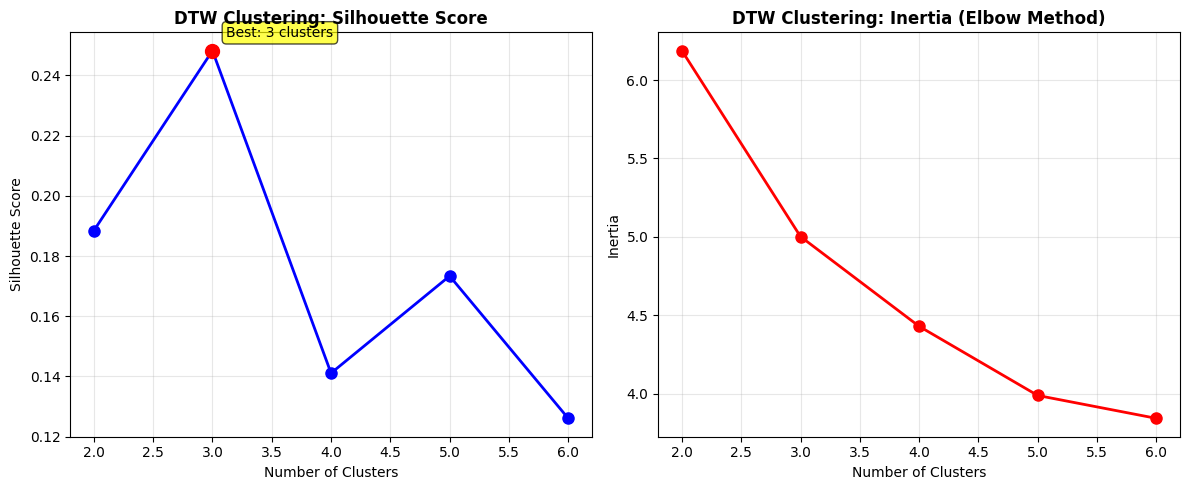

📊 CREATING DTW CLUSTERING VISUALIZATIONS


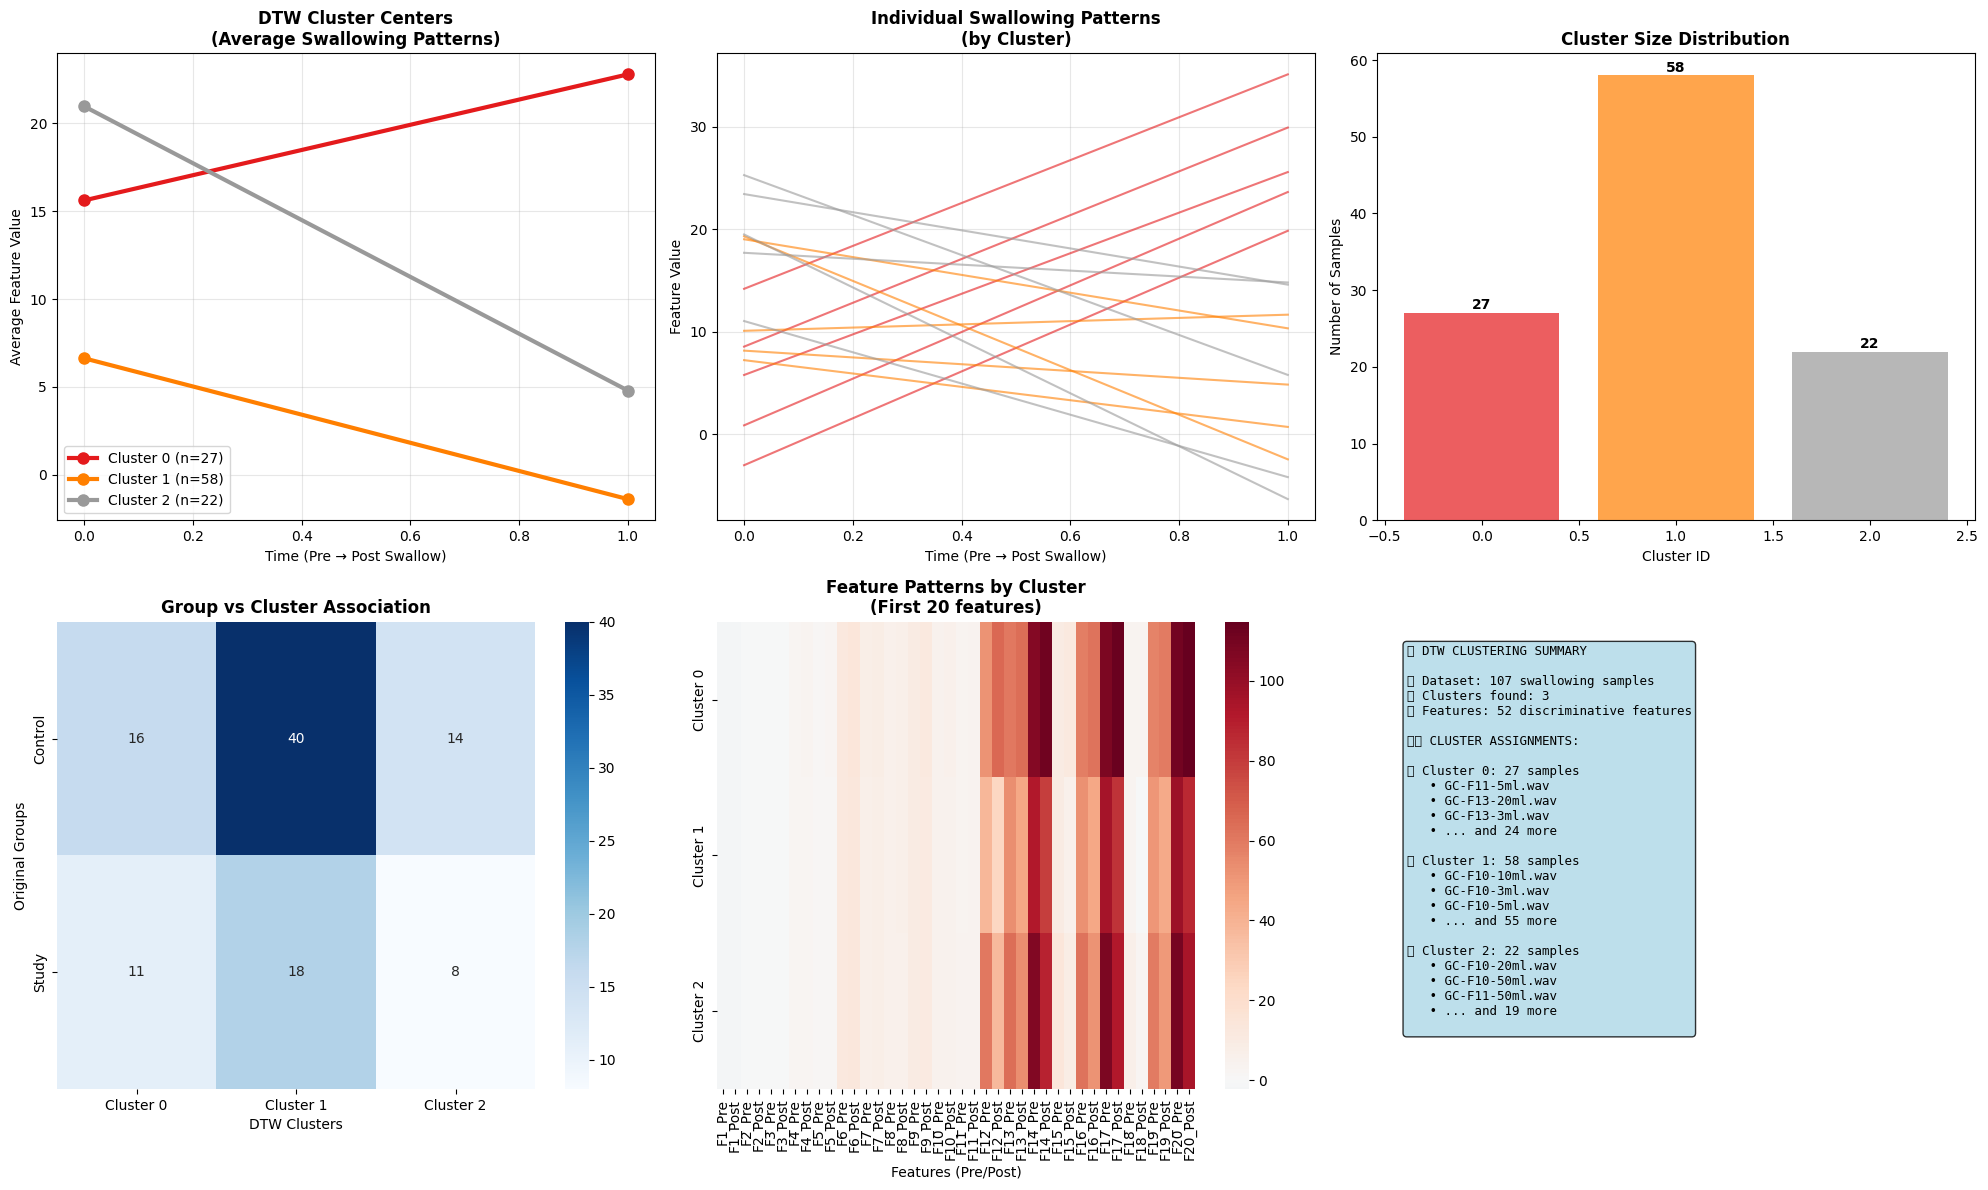

✅ DTW clustering visualizations completed!


In [62]:
# Cell 9: Create Visualizations
print("\n" + "="*60)

# Plot performance metrics
n_clusters_range = [2,3,4,5,6]
plot_clustering_performance(silhouette_scores, inertias, n_clusters_range)

# Create comprehensive DTW visualizations
visualize_dtw_results(ts_dataset, sample_names, best_labels, best_n_clusters, group_info)

In [63]:
# Cell 10: Final Results and Export
print("🎉 DTW ANALYSIS COMPLETE!")
print("=" * 40)
print(f"📊 {best_n_clusters} distinct swallowing patterns identified")
print(f"🏷️ Cluster assignments for {len(sample_names)} samples")

# Create results summary
dtw_results = {
    'ts_dataset': ts_dataset,
    'sample_names': sample_names,
    'cluster_labels': best_labels,
    'n_clusters': best_n_clusters,
    'model': best_model,
    'all_results': results,
    'pre_cols': pre_cols,
    'post_cols': post_cols,
    'silhouette_scores': silhouette_scores,
    'inertias': inertias
}

# Show cluster assignments
results_df = pd.DataFrame({
    'Sample': sample_names,
    'DTW_Cluster': best_labels,
    'Group': group_info.iloc[:, 0].values if group_info is not None else ['Unknown'] * len(sample_names)
})

print("\n📋 SAMPLE CLUSTER ASSIGNMENTS:")
print(results_df.head(10))

print(f"\n✅ Results saved in 'dtw_results' dictionary")
print(f"✅ Sample assignments in 'results_df' DataFrame")

🎉 DTW ANALYSIS COMPLETE!
📊 3 distinct swallowing patterns identified
🏷️ Cluster assignments for 107 samples

📋 SAMPLE CLUSTER ASSIGNMENTS:
            Sample  DTW_Cluster    Group
0  GC-F10-10ml.wav            1  Control
1  GC-F10-20ml.wav            2  Control
2   GC-F10-3ml.wav            1  Control
3  GC-F10-50ml.wav            2  Control
4   GC-F10-5ml.wav            1  Control
5  GC-F11-10ml.wav            1  Control
6  GC-F11-20ml.wav            1  Control
7   GC-F11-3ml.wav            1  Control
8  GC-F11-50ml.wav            2  Control
9   GC-F11-5ml.wav            0  Control

✅ Results saved in 'dtw_results' dictionary
✅ Sample assignments in 'results_df' DataFrame


In [64]:
# Cell: 2D Cluster Plot with Multiple Projections
def create_cluster_plots(ts_dataset, sample_names, cluster_labels, n_clusters, group_info=None):
    """
    Create 2D cluster plots using different dimensionality reduction methods
    """
    print("🗺️ CREATING 2D CLUSTER PLOTS")
    print("=" * 35)
    
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler
    import matplotlib.pyplot as plt
    
    # Prepare data: flatten time series for dimensionality reduction
    flattened_data = ts_dataset.reshape(ts_dataset.shape[0], -1)
    
    # Standardize the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(flattened_data)
    
    # Color palette
    colors = plt.cm.Set1(np.linspace(0, 1, n_clusters))
    cluster_colors = [colors[label] for label in cluster_labels]
    
    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. PCA Plot
    print("🔄 Computing PCA...")
    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(scaled_data)
    
    ax1 = axes[0, 0]
    scatter1 = ax1.scatter(pca_data[:, 0], pca_data[:, 1], 
                          c=cluster_colors, s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    # Add cluster labels to points
    for i, (x, y) in enumerate(pca_data):
        if i < 10:  # Label first 10 points to avoid crowding
            ax1.annotate(f'{cluster_labels[i]}', (x, y), xytext=(2, 2), 
                        textcoords='offset points', fontsize=8, alpha=0.7)
    
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax1.set_title('PCA Cluster Plot', fontweight='bold', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # Add legend
    for i in range(n_clusters):
        ax1.scatter([], [], c=[colors[i]], s=100, label=f'Cluster {i}')
    ax1.legend()
    
    # 2. t-SNE Plot
    print("🔄 Computing t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(scaled_data)//4))
    tsne_data = tsne.fit_transform(scaled_data)
    
    ax2 = axes[0, 1]
    scatter2 = ax2.scatter(tsne_data[:, 0], tsne_data[:, 1], 
                          c=cluster_colors, s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    ax2.set_xlabel('t-SNE Dimension 1')
    ax2.set_ylabel('t-SNE Dimension 2')
    ax2.set_title('t-SNE Cluster Plot', fontweight='bold', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    # Add legend
    for i in range(n_clusters):
        ax2.scatter([], [], c=[colors[i]], s=100, label=f'Cluster {i}')
    ax2.legend()
    
    # 3. DTW Distance-based MDS (if time allows)
    ax3 = axes[0, 2]
    try:
        print("🔄 Computing DTW-based MDS...")
        from sklearn.manifold import MDS
        from tslearn.metrics import dtw
        
        # Calculate DTW distance matrix (sample for speed)
        n_samples = min(50, len(ts_dataset))
        indices = np.random.choice(len(ts_dataset), n_samples, replace=False)
        sample_ts = ts_dataset[indices]
        sample_labels = cluster_labels[indices]
        sample_colors = [colors[label] for label in sample_labels]
        
        # DTW distance matrix
        distance_matrix = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(i+1, n_samples):
                dist = dtw(sample_ts[i], sample_ts[j])
                distance_matrix[i, j] = distance_matrix[j, i] = dist
        
        # MDS embedding
        mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
        mds_data = mds.fit_transform(distance_matrix)
        
        ax3.scatter(mds_data[:, 0], mds_data[:, 1], 
                   c=sample_colors, s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
        
        ax3.set_xlabel('MDS Dimension 1')
        ax3.set_ylabel('MDS Dimension 2')
        ax3.set_title('DTW-based MDS Plot', fontweight='bold', fontsize=14)
        ax3.grid(True, alpha=0.3)
        
        # Add legend
        for i in range(n_clusters):
            ax3.scatter([], [], c=[colors[i]], s=100, label=f'Cluster {i}')
        ax3.legend()
        
    except Exception as e:
        ax3.text(0.5, 0.5, f'DTW MDS failed:\n{str(e)[:50]}...', 
                ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('DTW-based MDS Plot', fontweight='bold', fontsize=14)
    
    # 4. Group Overlay (if available)
    if group_info is not None:
        ax4 = axes[1, 0]
        groups = group_info.iloc[:, 0].values
        unique_groups = np.unique(groups)
        group_markers = ['o', 's', '^', 'D', 'v']  # Different shapes for groups
        
        for i, group in enumerate(unique_groups):
            group_indices = groups == group
            group_pca = pca_data[group_indices]
            group_cluster_labels = cluster_labels[group_indices]
            
            for cluster_id in range(n_clusters):
                cluster_in_group = group_cluster_labels == cluster_id
                if np.any(cluster_in_group):
                    ax4.scatter(group_pca[cluster_in_group, 0], group_pca[cluster_in_group, 1],
                               c=[colors[cluster_id]], s=120, alpha=0.8, 
                               marker=group_markers[i % len(group_markers)],
                               edgecolors='black', linewidth=1,
                               label=f'{group} - C{cluster_id}' if cluster_id == 0 else '')
        
        ax4.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
        ax4.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
        ax4.set_title('Clusters by Original Groups', fontweight='bold', fontsize=14)
        ax4.grid(True, alpha=0.3)
        ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
    else:
        ax4 = axes[1, 0]
        ax4.text(0.5, 0.5, 'No group information\navailable', 
                ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.set_title('Groups Analysis', fontweight='bold', fontsize=14)
    
    # 5. Cluster Boundaries (Convex Hull)
    ax5 = axes[1, 1]
    from scipy.spatial import ConvexHull
    
    # Plot PCA again with convex hulls
    ax5.scatter(pca_data[:, 0], pca_data[:, 1], 
               c=cluster_colors, s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    # Draw convex hull for each cluster
    for cluster_id in range(n_clusters):
        cluster_indices = cluster_labels == cluster_id
        cluster_points = pca_data[cluster_indices]
        
        if len(cluster_points) > 2:  # Need at least 3 points for convex hull
            try:
                hull = ConvexHull(cluster_points)
                for simplex in hull.simplices:
                    ax5.plot(cluster_points[simplex, 0], cluster_points[simplex, 1], 
                            color=colors[cluster_id], alpha=0.3, linewidth=2)
                
                # Fill the hull
                hull_points = cluster_points[hull.vertices]
                ax5.fill(hull_points[:, 0], hull_points[:, 1], 
                        color=colors[cluster_id], alpha=0.1)
            except:
                pass  # Skip if hull calculation fails
    
    ax5.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax5.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax5.set_title('Cluster Boundaries (Convex Hull)', fontweight='bold', fontsize=14)
    ax5.grid(True, alpha=0.3)
    
    # Add legend
    for i in range(n_clusters):
        ax5.scatter([], [], c=[colors[i]], s=100, label=f'Cluster {i}')
    ax5.legend()
    
    # 6. Sample Names (Interactive-style)
    ax6 = axes[1, 2]
    
    # Create a zoomed-in view of interesting region or cluster centers
    scatter6 = ax6.scatter(pca_data[:, 0], pca_data[:, 1], 
                          c=cluster_colors, s=120, alpha=0.8, edgecolors='black', linewidth=1)
    
    # Add sample names for a subset of points (avoid overcrowding)
    step = max(1, len(sample_names) // 20)  # Show every nth sample
    for i in range(0, len(sample_names), step):
        ax6.annotate(sample_names[i], 
                    (pca_data[i, 0], pca_data[i, 1]), 
                    xytext=(3, 3), textcoords='offset points', 
                    fontsize=8, alpha=0.8, 
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[cluster_labels[i]], alpha=0.3))
    
    ax6.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax6.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax6.set_title('Sample Labels (Subset)', fontweight='bold', fontsize=14)
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print cluster statistics
    print("\n📊 CLUSTER PLOT STATISTICS:")
    print(f"   • Total samples: {len(sample_names)}")
    print(f"   • PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}")
    
    for i in range(n_clusters):
        cluster_size = np.sum(cluster_labels == i)
        percentage = (cluster_size / len(cluster_labels)) * 100
        print(f"   • Cluster {i}: {cluster_size} samples ({percentage:.1f}%)")
    
    print("✅ 2D cluster plots created!")
    
    return pca_data, tsne_data

print("✅ 2D cluster plot function defined!")

✅ 2D cluster plot function defined!


🗺️ CREATING 2D CLUSTER PLOTS
🔄 Computing PCA...
🔄 Computing t-SNE...
🔄 Computing DTW-based MDS...


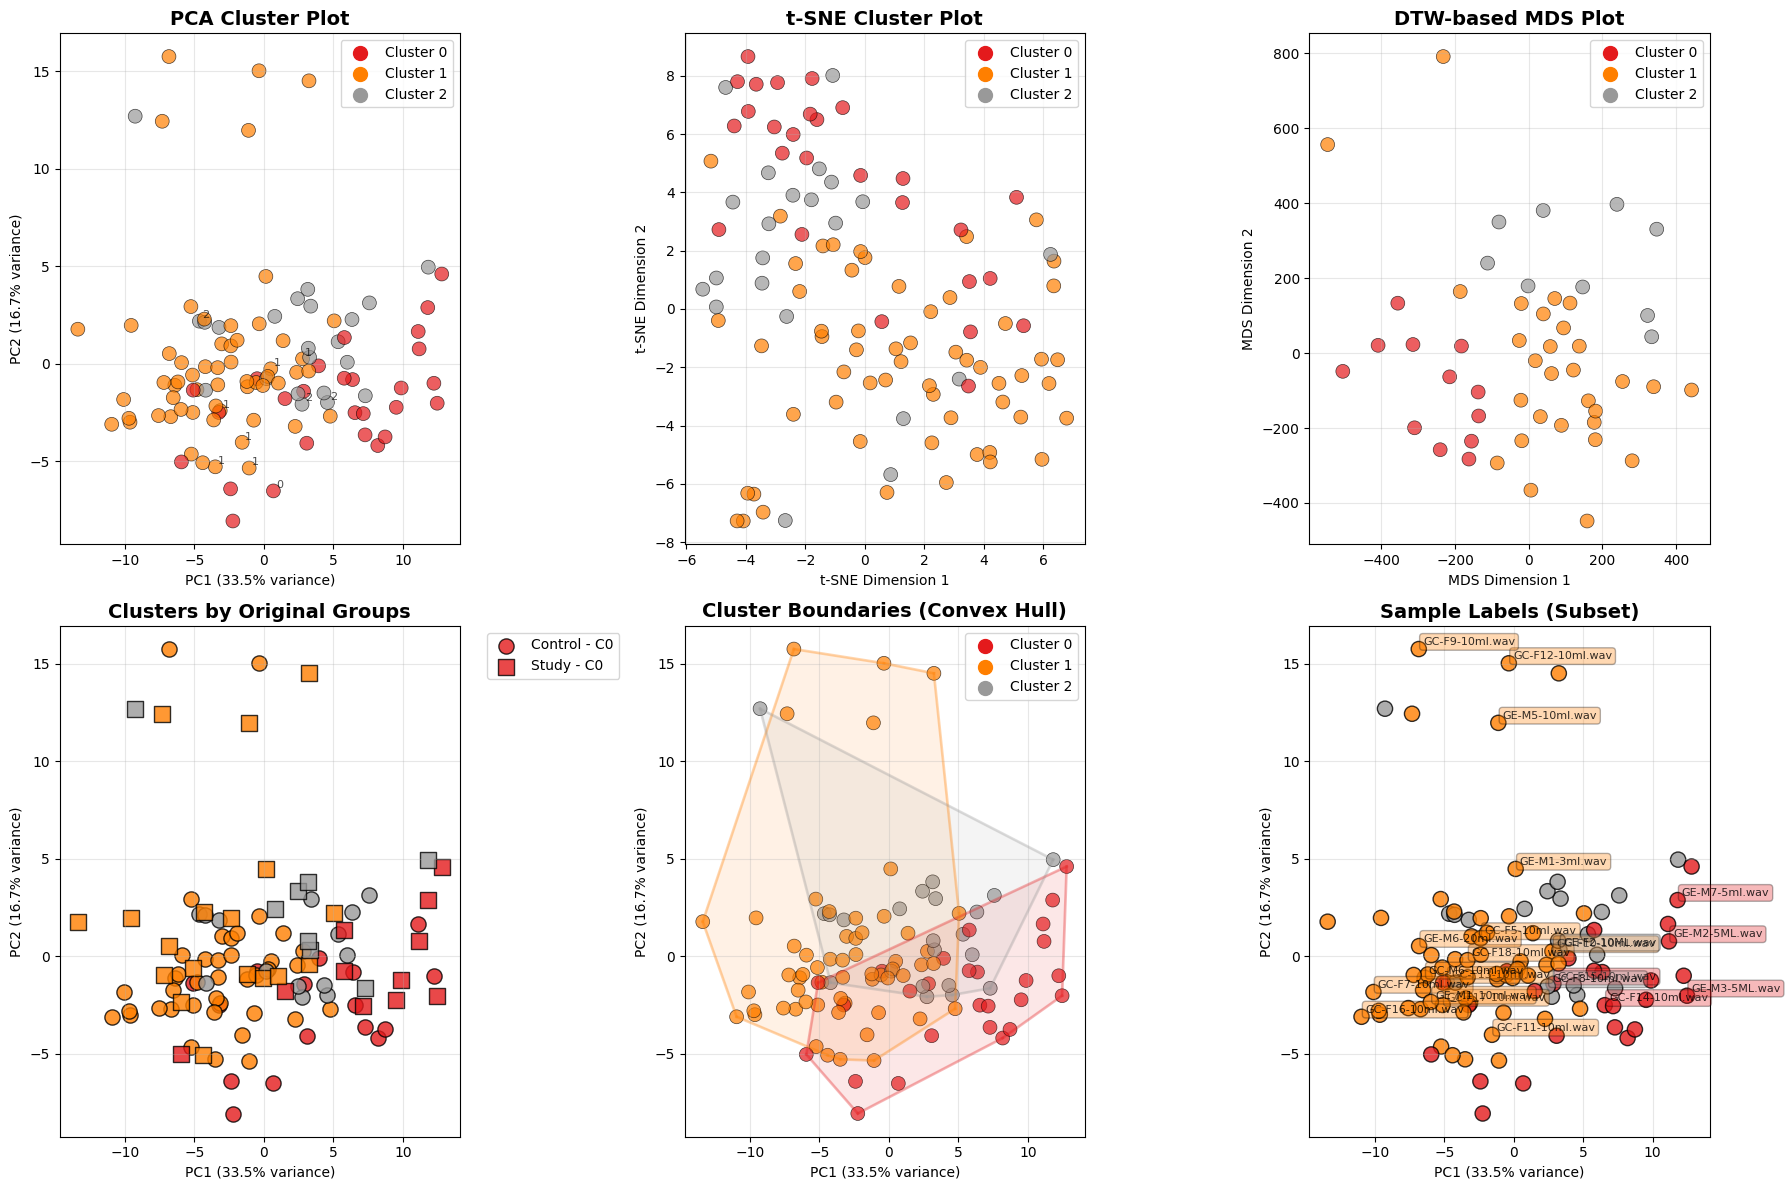


📊 CLUSTER PLOT STATISTICS:
   • Total samples: 107
   • PCA explained variance: 50.2%
   • Cluster 0: 27 samples (25.2%)
   • Cluster 1: 58 samples (54.2%)
   • Cluster 2: 22 samples (20.6%)
✅ 2D cluster plots created!


In [65]:
# Run the 2D cluster visualization
pca_results, tsne_results = create_cluster_plots(
    ts_dataset=ts_dataset,
    sample_names=sample_names,
    cluster_labels=best_labels,
    n_clusters=best_n_clusters,
    group_info=group_info
)